# Yield Engineering

## Objective
Identify population-level yield structure, evaluate measured yield-limiting candidates, investigate upstream process associations, and screen for unusual lot-level yield excursions.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

pd.set_option("display.max_columns", None)
pd.set_option("display.max_rows", 200)
pd.set_option("display.width", 200)
pd.set_option("display.max_colwidth", 100)

DATA_PATH = Path("./semiconductor_yield.csv")

In [2]:
df = pd.read_csv(DATA_PATH)

print("Dataset loaded successfully.")
print(f"Rows:    {df.shape[0]:,}")
print(f"Columns: {df.shape[1]:,}")

Dataset loaded successfully.
Rows:    1,250
Columns: 28


## Analysis Structure
Wafers are nested within lots. Lot-level factors are analyzed using one observation per lot; wafer-level relationships are evaluated within technology node and, where appropriate, with lot-clustered uncertainty estimates.


In [3]:
# Convert date
df["process_date"] = pd.to_datetime(df["process_date"])

# Basic dataset checks
print("Dataset shape:", df.shape)
print("Number of lots:", df["lot_id"].nunique())
print("Number of wafer IDs:", df["wafer_id"].nunique())
print("Missing values:", df.isna().sum().sum())
print("Duplicate lot-wafer records:",
      df.duplicated(["lot_id", "wafer_id"]).sum())

print("\nYield range:")
print(df["yield"].agg(["min", "max"]))

print("\nWafers per lot:")
print(df.groupby("lot_id").size().describe())


# Identify variables that are constant or varying within lots
within_lot = df.groupby("lot_id").nunique()

structure = pd.DataFrame({
    "min_unique_within_lot": within_lot.min(),
    "max_unique_within_lot": within_lot.max()
})

structure["level"] = np.where(
    structure["max_unique_within_lot"] == 1,
    "Lot-level",
    "Wafer-level"
)

structure = structure.drop(index=["lot_id"], errors="ignore")

print("\nVariable structure:")
display(structure)


# Separate variables for later analysis
lot_level_variables = structure.index[
    structure["level"] == "Lot-level"
].tolist()

wafer_level_variables = structure.index[
    structure["level"] == "Wafer-level"
].tolist()

print("\nLot-level variables:")
print(lot_level_variables)

print("\nWafer-level variables:")
print(wafer_level_variables)

Dataset shape: (1250, 28)
Number of lots: 50
Number of wafer IDs: 25
Missing values: 0
Duplicate lot-wafer records: 0

Yield range:
min    0.148086
max    0.982489
Name: yield, dtype: float64

Wafers per lot:
count    50.0
mean     25.0
std       0.0
min      25.0
25%      25.0
50%      25.0
75%      25.0
max      25.0
dtype: float64

Variable structure:


,min_unique_within_lot,max_unique_within_lot,level
wafer_id,25,25,Wafer-level
product_type,1,1,Lot-level
technology_node,1,1,Lot-level
process_date,1,1,Lot-level
etch_tool,1,1,Lot-level
litho_tool,1,1,Lot-level
deposition_tool,1,1,Lot-level
implant_tool,1,1,Lot-level
etch_rate,25,25,Wafer-level
pressure,25,25,Wafer-level



Lot-level variables:
['product_type', 'technology_node', 'process_date', 'etch_tool', 'litho_tool', 'deposition_tool', 'implant_tool']

Wafer-level variables:
['wafer_id', 'etch_rate', 'pressure', 'temperature', 'exposure_time', 'focus_offset', 'dose', 'deposition_rate', 'thickness_uniformity', 'implant_energy', 'tilt_angle', 'critical_dimension', 'oxide_thickness', 'resistivity', 'defect_count', 'defect_density', 'vth', 'leakage_current', 'resistance', 'yield']


## Yield Baseline and Technology-Node Effects


Overall Wafer Yield Summary


,yield
count,1250.000000
mean,0.456679
std,0.175306
min,0.148086
5%,0.230708
10%,0.254284
25%,0.323588
50%,0.415796
75%,0.573955
90%,0.720128


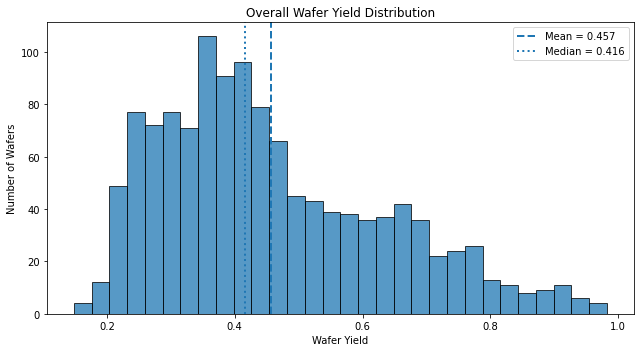

In [4]:
# YIELD BASELINE AND SEGMENTATION
# Overall wafer-level yield summary
yield_summary = df["yield"].describe(
    percentiles=[0.05, 0.10, 0.25, 0.50, 0.75, 0.90, 0.95]
)

print("Overall Wafer Yield Summary")
display(yield_summary.to_frame("yield"))


# Yield distribution
plt.figure(figsize=(9, 5))
plt.hist(df["yield"], bins=30, edgecolor="black", alpha=0.75)

plt.axvline(
    df["yield"].mean(),
    linestyle="--",
    linewidth=2,
    label=f'Mean = {df["yield"].mean():.3f}'
)

plt.axvline(
    df["yield"].median(),
    linestyle=":",
    linewidth=2,
    label=f'Median = {df["yield"].median():.3f}'
)

plt.xlabel("Wafer Yield")
plt.ylabel("Number of Wafers")
plt.title("Overall Wafer Yield Distribution")
plt.legend()
plt.tight_layout()
plt.show()



### Lot-Level Multi-Way ANOVA
Lot mean yield is modeled against technology node, product type, and tool assignments. Using lot means avoids treating the 25 wafers in a lot as independent replications of lot-level factors.


In [8]:
lot_model = (
    df.groupby("lot_id")
      .agg(
          mean_yield=("yield", "mean"),
          technology_node=("technology_node", "first"),
          product_type=("product_type", "first"),
          etch_tool=("etch_tool", "first"),
          litho_tool=("litho_tool", "first"),
          deposition_tool=("deposition_tool", "first"),
          implant_tool=("implant_tool", "first"),
          process_date=("process_date", "first"),
          n_wafers=("wafer_id", "size")
      )
      .reset_index()
)


display(lot_model.head())

,lot_id,mean_yield,technology_node,product_type,etch_tool,litho_tool,deposition_tool,implant_tool,process_date,n_wafers
0,LOT_0001,0.694157,10nm,CPU,ETCH_02,LITHO_01,DEP_03,IMP_01,2023-01-01,25
1,LOT_0002,0.373447,22nm,FPGA,ETCH_02,LITHO_04,DEP_03,IMP_02,2023-01-02,25
2,LOT_0003,0.633716,10nm,CPU,ETCH_04,LITHO_03,DEP_02,IMP_01,2023-01-03,25
3,LOT_0004,0.334892,14nm,GPU,ETCH_01,LITHO_01,DEP_02,IMP_01,2023-01-04,25
4,LOT_0005,0.373775,14nm,Memory,ETCH_05,LITHO_03,DEP_01,IMP_03,2023-01-05,25


In [10]:

import statsmodels.api as sm
import statsmodels.formula.api as smf

anova_model = smf.ols(
    """
    mean_yield ~
    C(technology_node) +
    C(product_type) +
    C(etch_tool) +
    C(litho_tool) +
    C(deposition_tool) +
    C(implant_tool)
    """,
    data=lot_model
).fit()

anova_table = sm.stats.anova_lm(
    anova_model,
    typ=2
)

display(anova_table.round(4))

,sum_sq,df,F,PR(>F)
C(technology_node),0.4392,4.0,80.2295,0.0000
C(product_type),0.0072,4.0,1.3239,0.2838
C(etch_tool),0.0008,4.0,0.1447,0.9639
C(litho_tool),0.0079,3.0,1.9130,0.1487
C(deposition_tool),0.0008,2.0,0.2797,0.7580
C(implant_tool),0.0065,2.0,2.3793,0.1099
Residual,0.0411,30.0,NaN,NaN


,count,mean,std,median,min,max
technology_node,,,,,,
10nm,15,0.5943,0.0537,0.5815,0.5146,0.6942
7nm,8,0.5833,0.0299,0.5794,0.5391,0.6345
28nm,12,0.3445,0.0228,0.3397,0.3100,0.3819
14nm,10,0.3419,0.0192,0.3352,0.3123,0.3738
22nm,5,0.3401,0.0247,0.3312,0.3150,0.3734


<Figure size 576x360 with 0 Axes>

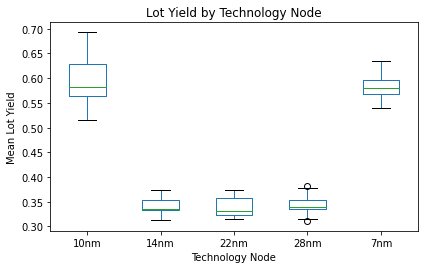

In [11]:
# Yield distribution across technology nodes at the lot level

node_summary = (
    lot_model.groupby("technology_node")["mean_yield"]
    .agg(["count", "mean", "std", "median", "min", "max"])
    .sort_values("mean", ascending=False)
)

display(node_summary.round(4))


plt.figure(figsize=(8, 5))

lot_model.boxplot(
    column="mean_yield",
    by="technology_node",
    grid=False
)

plt.xlabel("Technology Node")
plt.ylabel("Mean Lot Yield")
plt.title("Lot Yield by Technology Node")
plt.suptitle("")
plt.tight_layout()
plt.show()

In [12]:

import itertools
from patsy import build_design_matrices
from statsmodels.stats.multitest import multipletests

nodes = sorted(lot_model["technology_node"].unique())

# Create a balanced reference grid:
# every node is evaluated across the same product/tool combinations
factors = [
    "product_type",
    "etch_tool",
    "litho_tool",
    "deposition_tool",
    "implant_tool"
]

reference_grid = (
    lot_model[factors]
    .drop_duplicates()
    .reset_index(drop=True)
)

adjusted_vectors = {}
adjusted_means = {}

design_info = anova_model.model.data.design_info

for node in nodes:
    grid = reference_grid.copy()
    grid["technology_node"] = node

    X_grid = build_design_matrices(
        [design_info],
        grid,
        return_type="dataframe"
    )[0]

    L = X_grid.mean(axis=0).values

    adjusted_vectors[node] = L
    adjusted_means[node] = float(L @ anova_model.params.values)

adjusted_means = pd.DataFrame({
    "technology_node": nodes,
    "adjusted_mean_yield": [adjusted_means[n] for n in nodes]
})

print("Adjusted Mean Yield by Technology Node")
display(adjusted_means.round(4))


# Pairwise contrasts
results = []

for node1, node2 in itertools.combinations(nodes, 2):

    contrast = (
        adjusted_vectors[node1] -
        adjusted_vectors[node2]
    )

    test = anova_model.t_test(contrast)

    results.append({
        "comparison": f"{node1} - {node2}",
        "difference": float(test.effect),
        "ci_lower": float(test.conf_int()[0, 0]),
        "ci_upper": float(test.conf_int()[0, 1]),
        "p_value": float(test.pvalue)
    })

pairwise = pd.DataFrame(results)

# Holm correction for the 10 simultaneous comparisons
pairwise["p_adjusted"] = multipletests(
    pairwise["p_value"],
    method="holm"
)[1]

display(pairwise.round(4))

Adjusted Mean Yield by Technology Node


,technology_node,adjusted_mean_yield
0,10nm,0.5932
1,14nm,0.3385
2,22nm,0.3667
3,28nm,0.3508
4,7nm,0.5664


,comparison,difference,ci_lower,ci_upper,p_value,p_adjusted
0,10nm - 14nm,0.2547,0.2181,0.2913,0.0000,0.0000
1,10nm - 22nm,0.2264,0.1744,0.2785,0.0000,0.0000
2,10nm - 28nm,0.2424,0.2056,0.2791,0.0000,0.0000
3,10nm - 7nm,0.0268,-0.0180,0.0717,0.2318,0.9272
4,14nm - 22nm,-0.0283,-0.0800,0.0234,0.2728,0.9272
5,14nm - 28nm,-0.0124,-0.0520,0.0273,0.5285,1.0000
6,14nm - 7nm,-0.2279,-0.2737,-0.1822,0.0000,0.0000
7,22nm - 28nm,0.0159,-0.0341,0.0659,0.5204,1.0000
8,22nm - 7nm,-0.1996,-0.2564,-0.1429,0.0000,0.0000
9,28nm - 7nm,-0.2156,-0.2628,-0.1683,0.0000,0.0000


## Wafer-Level Yield Associations
Correlations are evaluated within technology node to avoid allowing node-level baseline differences to create misleading pooled relationships.


In [13]:
defect_corr = (
    df.groupby("technology_node")
      .apply(lambda x: x["defect_density"].corr(x["yield"]))
      .rename("correlation")
      .sort_values()
)

display(defect_corr.round(3))

technology_node
22nm   -0.370
7nm    -0.368
10nm   -0.351
14nm   -0.291
28nm   -0.276
Name: correlation, dtype: float64

In [14]:
cd_corr = (
    df.groupby("technology_node")
      .apply(lambda x: x["critical_dimension"].corr(x["yield"]))
      .rename("correlation")
      .sort_values()
)

display(cd_corr.round(3))


technology_node
14nm   -0.276
10nm   -0.263
28nm   -0.231
7nm    -0.044
22nm   -0.025
Name: correlation, dtype: float64

In [15]:
oxide_corr = (
    df.groupby("technology_node")
      .apply(lambda x: x["oxide_thickness"].corr(x["yield"]))
      .rename("correlation")
      .sort_values()
)

display(oxide_corr.round(3))

technology_node
22nm   -0.231
28nm   -0.123
14nm   -0.094
10nm    0.100
7nm     0.118
Name: correlation, dtype: float64

In [16]:
resistivity_corr = (
    df.groupby("technology_node")
      .apply(lambda x: x["resistivity"].corr(x["yield"]))
      .rename("correlation")
      .sort_values()
)

display(resistivity_corr.round(3))

technology_node
7nm     0.000
14nm    0.000
28nm    0.040
10nm    0.047
22nm    0.103
Name: correlation, dtype: float64

In [17]:
vth_corr = (
    df.groupby("technology_node")
      .apply(lambda x: x["vth"].corr(x["yield"]))
      .rename("correlation")
      .sort_values()
)

display(vth_corr.round(3))

technology_node
10nm   -0.372
7nm    -0.357
28nm   -0.246
22nm   -0.240
14nm   -0.218
Name: correlation, dtype: float64

In [18]:
leakage_corr = (
    df.groupby("technology_node")
      .apply(lambda x: x["leakage_current"].corr(x["yield"]))
      .rename("correlation")
      .sort_values()
)

display(leakage_corr.round(3))

technology_node
22nm   -0.198
10nm   -0.173
14nm   -0.154
7nm    -0.111
28nm   -0.053
Name: correlation, dtype: float64

In [19]:
resistance_corr = (
    df.groupby("technology_node")
      .apply(lambda x: x["resistance"].corr(x["yield"]))
      .rename("correlation")
      .sort_values()
)

display(resistance_corr.round(3))

technology_node
22nm   -0.164
28nm   -0.063
14nm   -0.010
10nm    0.026
7nm     0.032
Name: correlation, dtype: float64

In [20]:
defect_vth_corr = (
    df.groupby("technology_node")
      .apply(lambda x: x["defect_density"].corr(x["vth"]))
      .rename("correlation")
      .sort_values()
)

display(defect_vth_corr.round(3))

technology_node
10nm    0.137
7nm     0.236
28nm    0.237
14nm    0.281
22nm    0.378
Name: correlation, dtype: float64

In [21]:
import statsmodels.api as sm
from sklearn.preprocessing import StandardScaler

results = []

for node, group in df.groupby("technology_node"):
    X = group[["defect_density", "vth"]]
    y = group["yield"]

    X_scaled = pd.DataFrame(
        StandardScaler().fit_transform(X),
        columns=X.columns,
        index=X.index
    )

    X_scaled = sm.add_constant(X_scaled)

    model = sm.OLS(y, X_scaled).fit()

    results.append({
        "technology_node": node,
        "defect_density_coef": model.params["defect_density"],
        "vth_coef": model.params["vth"],
        "R_squared": model.rsquared
    })

joint_results = pd.DataFrame(results)

display(joint_results.round(3))

,technology_node,defect_density_coef,vth_coef,R_squared
0,10nm,-0.048,-0.052,0.230
1,14nm,-0.023,-0.014,0.105
2,22nm,-0.030,-0.011,0.149
3,28nm,-0.020,-0.017,0.111
4,7nm,-0.045,-0.043,0.213


In [22]:
etch_corr = (
    df.groupby("technology_node")
      .apply(lambda x: x["etch_rate"].corr(x["yield"]))
      .rename("correlation")
      .sort_values()
)

display(etch_corr.round(3))

technology_node
14nm   -0.197
10nm   -0.131
7nm    -0.106
22nm   -0.089
28nm    0.117
Name: correlation, dtype: float64

In [23]:
pressure_corr = (
    df.groupby("technology_node")
      .apply(lambda x: x["pressure"].corr(x["yield"]))
      .rename("correlation")
      .sort_values()
)

display(pressure_corr.round(3))

technology_node
7nm    -0.092
10nm   -0.055
14nm   -0.055
22nm   -0.049
28nm   -0.004
Name: correlation, dtype: float64

In [24]:
temperature_corr = (
    df.groupby("technology_node")
      .apply(lambda x: x["temperature"].corr(x["yield"]))
      .rename("correlation")
      .sort_values()
)

display(temperature_corr.round(3))

technology_node
22nm   -0.145
10nm   -0.059
14nm   -0.048
28nm   -0.030
7nm     0.012
Name: correlation, dtype: float64

In [25]:
exposure_corr = (
    df.groupby("technology_node")
      .apply(lambda x: x["exposure_time"].corr(x["yield"]))
      .rename("correlation")
      .sort_values()
)

display(exposure_corr.round(3))

technology_node
22nm   -0.172
28nm   -0.109
10nm   -0.049
7nm    -0.001
14nm    0.015
Name: correlation, dtype: float64

In [26]:
focus_corr = (
    df.groupby("technology_node")
      .apply(lambda x: x["focus_offset"].corr(x["yield"]))
      .rename("correlation")
      .sort_values()
)

display(focus_corr.round(3))

technology_node
22nm   -0.170
10nm   -0.115
28nm   -0.068
14nm   -0.023
7nm     0.008
Name: correlation, dtype: float64

In [27]:
deposition_corr = (
    df.groupby("technology_node")
      .apply(lambda x: x["deposition_rate"].corr(x["yield"]))
      .rename("correlation")
      .sort_values()
)

display(deposition_corr.round(3))

technology_node
28nm   -0.018
7nm     0.039
14nm    0.064
22nm    0.069
10nm    0.128
Name: correlation, dtype: float64

In [28]:
uniformity_corr = (
    df.groupby("technology_node")
      .apply(lambda x: x["thickness_uniformity"].corr(x["yield"]))
      .rename("correlation")
      .sort_values()
)

display(uniformity_corr.round(3))

technology_node
7nm    -0.370
22nm   -0.368
10nm   -0.352
14nm   -0.293
28nm   -0.277
Name: correlation, dtype: float64

In [29]:
uniformity_defect_corr = (
    df.groupby("technology_node")
      .apply(lambda x: x["thickness_uniformity"].corr(x["defect_density"]))
      .rename("correlation")
      .sort_values()
)

display(uniformity_defect_corr.round(4))

technology_node
22nm    0.9996
7nm     0.9996
14nm    0.9996
28nm    0.9997
10nm    0.9997
Name: correlation, dtype: float64

In [30]:
corr = (
    df.groupby("technology_node")
      .apply(lambda x: x["thickness_uniformity"].corr(x["vth"]))
      .sort_values()
)

corr.name = "correlation"
print(corr.round(3))

technology_node
10nm    0.138
7nm     0.236
28nm    0.237
14nm    0.283
22nm    0.375
Name: correlation, dtype: float64


In [31]:
corr = (
    df.groupby("technology_node")
      .apply(lambda x: x["critical_dimension"].corr(x["vth"]))
      .sort_values()
)

corr.name = "correlation"
print(corr.round(3))

technology_node
7nm     0.220
10nm    0.282
28nm    0.286
22nm    0.331
14nm    0.578
Name: correlation, dtype: float64


In [32]:
corr = (
    df.groupby("technology_node")
      .apply(lambda x: x["oxide_thickness"].corr(x["vth"]))
      .sort_values()
)

corr.name = "correlation"
print(corr.round(3))

technology_node
28nm   -0.109
14nm   -0.057
7nm    -0.037
22nm    0.009
10nm    0.019
Name: correlation, dtype: float64


### Correlation Screen Across Measured Variables


In [33]:
numeric_vars = [
    "etch_rate",
    "pressure",
    "temperature",
    "exposure_time",
    "focus_offset",
    "dose",
    "deposition_rate",
    "thickness_uniformity",
    "implant_energy",
    "tilt_angle",
    "critical_dimension",
    "oxide_thickness",
    "resistivity",
    "defect_density",
    "vth",
    "leakage_current",
    "resistance",
    "yield"
]

corr_by_node = {
    node: group[numeric_vars].corr()
    for node, group in df.groupby("technology_node")
}

In [34]:
results = []

for node, corr_matrix in corr_by_node.items():
    for i, var1 in enumerate(numeric_vars):
        for var2 in numeric_vars[i + 1:]:
            r = corr_matrix.loc[var1, var2]

            if abs(r) >= 0.30:
                results.append({
                    "technology_node": node,
                    "variable_1": var1,
                    "variable_2": var2,
                    "correlation": r
                })

strong_corr = (
    pd.DataFrame(results)
    .assign(abs_correlation=lambda x: x["correlation"].abs())
    .sort_values("abs_correlation", ascending=False)
    .drop(columns="abs_correlation")
)

display(strong_corr.round(3))

,technology_node,variable_1,variable_2,correlation
3,10nm,thickness_uniformity,defect_density,1.000
31,28nm,thickness_uniformity,defect_density,1.000
15,14nm,thickness_uniformity,defect_density,1.000
36,7nm,thickness_uniformity,defect_density,1.000
23,22nm,thickness_uniformity,defect_density,1.000
17,14nm,critical_dimension,vth,0.578
34,28nm,resistivity,resistance,0.524
39,7nm,resistivity,resistance,0.520
18,14nm,resistivity,resistance,0.487
28,22nm,resistivity,resistance,0.477


## Yield-Limiter Model
Defect density, threshold voltage (`vth`), and critical dimension are modeled jointly with technology node. Thickness uniformity is excluded because it is nearly redundant with defect density.


In [35]:
import statsmodels.formula.api as smf
from patsy.builtins import Q
yield_model = smf.ols(
    """
    Q("yield") ~ defect_density
          + vth
          + critical_dimension
          + C(technology_node)
    """,
    data=df
).fit()

print(yield_model.summary())

                            OLS Regression Results                            
Dep. Variable:             Q("yield")   R-squared:                       0.580
Model:                            OLS   Adj. R-squared:                  0.578
Method:                 Least Squares   F-statistic:                     245.0
Date:                Wed, 23 Sep 2026   Prob (F-statistic):          8.72e-229
Time:                        14:09:37   Log-Likelihood:                 945.48
No. Observations:                1250   AIC:                            -1875.
Df Residuals:                    1242   BIC:                            -1834.
Df Model:                           7                                         
Covariance Type:            nonrobust                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

### Hierarchical and Robustness Checks


In [36]:
import statsmodels.formula.api as smf

mixed_model = smf.mixedlm(
    """
    Q("yield") ~ defect_density
          + vth
          + critical_dimension
          + C(technology_node)
    """,
    data=df,
    groups=df["lot_id"]
).fit()

print(mixed_model.summary())

                Mixed Linear Model Regression Results
Model:                  MixedLM     Dependent Variable:     Q("yield")
No. Observations:       1250        Method:                 REML      
No. Groups:             50          Scale:                  0.0128    
Min. group size:        25          Log-Likelihood:         916.8288  
Max. group size:        25          Converged:              Yes       
Mean group size:        25.0                                          
----------------------------------------------------------------------
                           Coef.  Std.Err.    z    P>|z| [0.025 0.975]
----------------------------------------------------------------------
Intercept                   1.291    0.051  25.273 0.000  1.191  1.391
C(technology_node)[T.14nm] -0.191    0.015 -12.520 0.000 -0.221 -0.161
C(technology_node)[T.22nm] -0.188    0.018 -10.609 0.000 -0.223 -0.153
C(technology_node)[T.28nm] -0.191    0.015 -12.753 0.000 -0.220 -0.162
C(technology_node)[T.7n

/Library/Frameworks/Python.framework/Versions/3.7/lib/python3.7/site-packages/statsmodels/regression/mixed_linear_model.py:2237: ConvergenceWarning: The MLE may be on the boundary of the parameter space.
  warnings.warn(msg, ConvergenceWarning)


In [37]:
cluster_model = yield_model.get_robustcov_results(
    cov_type="cluster",
    groups=df["lot_id"]
)

print(cluster_model.summary())

                            OLS Regression Results                            
Dep. Variable:             Q("yield")   R-squared:                       0.580
Model:                            OLS   Adj. R-squared:                  0.578
Method:                 Least Squares   F-statistic:                     260.5
Date:                Wed, 23 Sep 2026   Prob (F-statistic):           1.71e-36
Time:                        14:09:40   Log-Likelihood:                 945.48
No. Observations:                1250   AIC:                            -1875.
Df Residuals:                    1242   BIC:                            -1834.
Df Model:                           7                                         
Covariance Type:              cluster                                         
                                 coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

### Node-Specific Effects
Standardized predictors are interacted with technology node to test whether their yield relationships differ across nodes.


In [38]:
from scipy.stats import zscore

df["defect_density_z"] = zscore(df["defect_density"])
df["vth_z"] = zscore(df["vth"])
df["critical_dimension_z"] = zscore(df["critical_dimension"])

In [39]:
interaction_model = smf.ols(
    """
    Q("yield") ~ C(technology_node) * (
        defect_density_z
        + vth_z
        + critical_dimension_z
    )
    """,
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["lot_id"]}
)

print(interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:             Q("yield")   R-squared:                       0.607
Model:                            OLS   Adj. R-squared:                  0.601
Method:                 Least Squares   F-statistic:                     496.6
Date:                Wed, 23 Sep 2026   Prob (F-statistic):           2.13e-49
Time:                        14:09:42   Log-Likelihood:                 986.88
No. Observations:                1250   AIC:                            -1934.
Df Residuals:                    1230   BIC:                            -1831.
Df Model:                          19                                         
Covariance Type:              cluster                                         
                                                      coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------

In [40]:
import statsmodels.api as sm
from statsmodels.stats.outliers_influence import variance_inflation_factor

X = df[["defect_density_z", "vth_z", "critical_dimension_z"]]
X = sm.add_constant(X)

vif = pd.DataFrame({
    "Variable": X.columns,
    "VIF": [
        variance_inflation_factor(X.values, i)
        for i in range(X.shape[1])
    ]
})

print(vif)

               Variable       VIF
0                 const  1.000000
1      defect_density_z  1.082213
2                 vth_z  1.697728
3  critical_dimension_z  1.725477


In [41]:
nodes = ["10nm", "14nm", "22nm", "28nm", "7nm"]

variables = [
    "defect_density_z",
    "vth_z",
    "critical_dimension_z"
]

effects = []

for node in nodes:
    row = {"technology_node": node}

    for var in variables:
        effect = interaction_model.params[var]

        if node != "10nm":
            interaction = f"C(technology_node)[T.{node}]:{var}"
            effect += interaction_model.params[interaction]

        row[var.replace("_z", "")] = effect

    effects.append(row)

effects_df = pd.DataFrame(effects)

print(effects_df.round(4))

  technology_node  defect_density     vth  critical_dimension
0            10nm         -0.0506 -0.0522             -0.0938
1            14nm         -0.0248 -0.0010             -0.0435
2            22nm         -0.0310 -0.0136              0.0038
3            28nm         -0.0199 -0.0154             -0.0300
4             7nm         -0.0478 -0.0546              0.0248


In [42]:

nodes = ["10nm", "14nm", "22nm", "28nm", "7nm"]
variables = ["defect_density_z", "vth_z", "critical_dimension_z"]

results = []

for node in nodes:
    for var in variables:
        hypothesis = var

        if node != "10nm":
            hypothesis += f" + C(technology_node)[T.{node}]:{var}"

        test = interaction_model.t_test(hypothesis)

        results.append({
            "technology_node": node,
            "variable": var.replace("_z", ""),
            "coefficient": float(test.effect),
            "ci_low": float(test.conf_int()[0, 0]),
            "ci_high": float(test.conf_int()[0, 1]),
            "p_value": float(test.pvalue)
        })

node_effects = pd.DataFrame(results)

print(node_effects.round(4))

   technology_node            variable  coefficient  ci_low  ci_high  p_value
0             10nm      defect_density      -0.0506 -0.0640  -0.0371   0.0000
1             10nm                 vth      -0.0522 -0.0706  -0.0337   0.0000
2             10nm  critical_dimension      -0.0938 -0.1408  -0.0467   0.0001
3             14nm      defect_density      -0.0248 -0.0310  -0.0186   0.0000
4             14nm                 vth      -0.0010 -0.0203   0.0184   0.9230
5             14nm  critical_dimension      -0.0435 -0.0775  -0.0094   0.0123
6             22nm      defect_density      -0.0310 -0.0447  -0.0174   0.0000
7             22nm                 vth      -0.0136 -0.0310   0.0038   0.1267
8             22nm  critical_dimension       0.0038 -0.0347   0.0422   0.8478
9             28nm      defect_density      -0.0199 -0.0314  -0.0085   0.0007
10            28nm                 vth      -0.0154 -0.0291  -0.0016   0.0284
11            28nm  critical_dimension      -0.0300 -0.0520  -0.

## Upstream Investigation of Defect Density
The measured process variables are screened as potential upstream correlates of defect density.

In [43]:
process_vars = [
    "etch_rate",
    "pressure",
    "temperature",
    "exposure_time",
    "focus_offset",
    "dose",
    "deposition_rate",
    "implant_energy",
    "tilt_angle"
]

defect_corr = (
    df.groupby("technology_node")[process_vars + ["defect_density"]]
      .corr()["defect_density"]
      .drop("defect_density", level=1)
      .unstack()
)

print(defect_corr.round(3))

                 etch_rate  pressure  temperature  exposure_time  focus_offset   dose  deposition_rate  implant_energy  tilt_angle
technology_node                                                                                                                   
10nm                 0.175     0.189        0.171          0.049         0.423 -0.054           -0.236          -0.083      -0.030
14nm                 0.415     0.104        0.221          0.027         0.295 -0.027           -0.341          -0.009       0.050
22nm                 0.173     0.025        0.146          0.053         0.284  0.070           -0.176           0.121       0.016
28nm                 0.127     0.016        0.121         -0.046         0.293  0.039           -0.178           0.047      -0.087
7nm                  0.206    -0.036        0.012         -0.117         0.180 -0.095           -0.169          -0.048       0.093


In [44]:
process_vars = [
    "etch_rate",
    "pressure",
    "temperature",
    "exposure_time",
    "focus_offset",
    "dose",
    "deposition_rate",
    "implant_energy",
    "tilt_angle"
]

for var in process_vars:
    df[f"{var}_z"] = zscore(df[var])

In [45]:
formula = """
defect_density ~ C(technology_node)
+ etch_rate_z
+ pressure_z
+ temperature_z
+ exposure_time_z
+ focus_offset_z
+ dose_z
+ deposition_rate_z
+ implant_energy_z
+ tilt_angle_z
"""

process_model = smf.ols(
    formula,
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["lot_id"]}
)

print(process_model.summary())

                            OLS Regression Results                            
Dep. Variable:         defect_density   R-squared:                       0.183
Model:                            OLS   Adj. R-squared:                  0.174
Method:                 Least Squares   F-statistic:                     15.04
Date:                Wed, 23 Sep 2026   Prob (F-statistic):           7.24e-13
Time:                        14:10:01   Log-Likelihood:                 1007.5
No. Observations:                1250   AIC:                            -1987.
Df Residuals:                    1236   BIC:                            -1915.
Df Model:                          13                                         
Covariance Type:              cluster                                         
                                 coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------------------
Intercept           

In [46]:
process_interaction_model = smf.ols(
    """
    defect_density ~ C(technology_node) * (
        focus_offset_z
        + etch_rate_z
        + deposition_rate_z
        + temperature_z
    )
    """,
    data=df
).fit(
    cov_type="cluster",
    cov_kwds={"groups": df["lot_id"]}
)

print(process_interaction_model.summary())

                            OLS Regression Results                            
Dep. Variable:         defect_density   R-squared:                       0.199
Model:                            OLS   Adj. R-squared:                  0.184
Method:                 Least Squares   F-statistic:                     26.91
Date:                Wed, 23 Sep 2026   Prob (F-statistic):           1.41e-20
Time:                        14:10:02   Log-Likelihood:                 1020.4
No. Observations:                1250   AIC:                            -1991.
Df Residuals:                    1225   BIC:                            -1863.
Df Model:                          24                                         
Covariance Type:              cluster                                         
                                                   coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------

## Residual Yield Check
Residuals are screened to determine whether remaining measured variables contain an obvious linear signal after the main yield model.


In [47]:
df["predicted_yield"] = interaction_model.predict(df)
df["yield_residual"] = df["yield"] - df["predicted_yield"]

print(df[["yield", "predicted_yield", "yield_residual"]].head(30))

       yield  predicted_yield  yield_residual
0   0.678783         0.664718        0.014066
1   0.779966         0.718335        0.061630
2   0.778492         0.718117        0.060375
3   0.405275         0.545084       -0.139809
4   0.935350         0.681490        0.253860
5   0.595224         0.671644       -0.076420
6   0.922865         0.797208        0.125657
7   0.390799         0.560347       -0.169548
8   0.891939         0.620881        0.271058
9   0.656926         0.666519       -0.009594
10  0.647824         0.636840        0.010984
11  0.527345         0.678219       -0.150875
12  0.735875         0.495934        0.239940
13  0.813455         0.760562        0.052893
14  0.940097         0.706442        0.233655
15  0.724747         0.707694        0.017053
16  0.678960         0.667498        0.011462
17  0.554267         0.582347       -0.028080
18  0.414777         0.614582       -0.199805
19  0.668262         0.507721        0.160541
20  0.747963         0.708115     

In [48]:
lot_residuals = (
    df.groupby("lot_id")["yield_residual"]
      .agg(["mean", "std", "min", "max"])
      .sort_values("mean")
)

print(lot_residuals.round(4))

            mean     std     min     max
lot_id                                  
LOT_0018 -0.0570  0.1129 -0.2212  0.2381
LOT_0010 -0.0495  0.1634 -0.3140  0.2879
LOT_0024 -0.0325  0.0999 -0.1898  0.3091
LOT_0037 -0.0325  0.1337 -0.3297  0.2062
LOT_0042 -0.0272  0.1340 -0.2316  0.1680
LOT_0044 -0.0210  0.1269 -0.2501  0.2570
LOT_0014 -0.0207  0.0870 -0.1681  0.1326
LOT_0022 -0.0184  0.1049 -0.1317  0.3324
LOT_0017 -0.0183  0.1203 -0.2471  0.2573
LOT_0020 -0.0182  0.1568 -0.2122  0.2604
LOT_0011 -0.0137  0.0999 -0.1621  0.1824
LOT_0004 -0.0114  0.0770 -0.1415  0.1621
LOT_0035 -0.0110  0.1549 -0.2081  0.2800
LOT_0050 -0.0104  0.1356 -0.2467  0.2262
LOT_0028 -0.0079  0.0926 -0.1836  0.2110
LOT_0007 -0.0073  0.0624 -0.1045  0.1065
LOT_0016 -0.0072  0.0710 -0.1014  0.1219
LOT_0048 -0.0072  0.0638 -0.1250  0.1077
LOT_0029 -0.0060  0.1017 -0.2032  0.3098
LOT_0030 -0.0055  0.1327 -0.1902  0.3059
LOT_0036 -0.0044  0.0765 -0.1226  0.1234
LOT_0039 -0.0031  0.0958 -0.1303  0.1921
LOT_0025 -0.0027

In [49]:
exclude = [
    "yield",
    "predicted_yield",
    "yield_residual",
    "defect_density",
    "thickness_uniformity",
    "vth",
    "critical_dimension"
]

numeric_vars = (
    df.select_dtypes(include="number")
      .columns
      .difference(exclude)
)

residual_correlations = (
    df[numeric_vars]
    .corrwith(df["yield_residual"])
    .sort_values(key=abs, ascending=False)
)

print(residual_correlations.round(3))

exposure_time_z        -0.054
exposure_time          -0.054
tilt_angle_z           -0.042
tilt_angle             -0.042
implant_energy          0.041
implant_energy_z        0.041
focus_offset            0.033
focus_offset_z          0.033
resistance             -0.028
dose_z                  0.028
dose                    0.028
leakage_current        -0.024
pressure               -0.024
pressure_z             -0.024
etch_rate_z            -0.022
etch_rate              -0.022
resistivity             0.013
oxide_thickness        -0.013
deposition_rate        -0.007
deposition_rate_z      -0.007
defect_count           -0.005
temperature             0.001
temperature_z           0.001
defect_density_z        0.000
vth_z                   0.000
critical_dimension_z    0.000
dtype: float64


## Lot-Level Excursion Analysis
A robust MAD score is calculated for lot mean yield within technology node. A score below −3 is used as a screening rule for unusually low-yield lots, not as an engineering specification limit.


In [50]:
def robust_score(x):
    median = x.median()
    mad = np.median(np.abs(x - median))

    if mad == 0:
        return pd.Series(np.nan, index=x.index)

    return (x - median) / (1.4826 * mad)


lot_model["robust_yield_score"] = (
    lot_model.groupby("technology_node")["mean_yield"]
    .transform(robust_score)
)

lot_excursions = (
    lot_model[
        [
            "lot_id",
            "technology_node",
            "mean_yield",
            "robust_yield_score"
        ]
    ]
    .sort_values("robust_yield_score")
)

display(lot_excursions.round(3))

,lot_id,technology_node,mean_yield,robust_yield_score
23,LOT_0024,28nm,0.310,-3.588
47,LOT_0048,28nm,0.314,-3.113
36,LOT_0037,7nm,0.539,-1.922
49,LOT_0050,10nm,0.515,-1.171
42,LOT_0043,14nm,0.312,-1.137
17,LOT_0018,10nm,0.517,-1.131
46,LOT_0047,7nm,0.561,-0.881
43,LOT_0044,10nm,0.543,-0.674
40,LOT_0041,22nm,0.315,-0.674
21,LOT_0022,28nm,0.335,-0.570


In [51]:
lot_model["low_yield_excursion"] = (
    lot_model["robust_yield_score"] < -3
)

display(
    lot_model.loc[
        lot_model["low_yield_excursion"],
        ["lot_id", "technology_node", "mean_yield", "robust_yield_score"]
    ].sort_values("robust_yield_score").round(3)
)

,lot_id,technology_node,mean_yield,robust_yield_score
23,LOT_0024,28nm,0.310,-3.588
47,LOT_0048,28nm,0.314,-3.113


### Process Comparison for 28nm Excursion Lots


In [52]:
# Compare excursion lots with the remaining 28nm lots
process_vars = [
    "etch_rate",
    "pressure",
    "temperature",
    "exposure_time",
    "focus_offset",
    "dose",
    "deposition_rate",
    "implant_energy",
    "tilt_angle"
]

excursion_lots = ["LOT_0024", "LOT_0048"]

comparison = (
    df[df["technology_node"] == "28nm"]
    .assign(
        group=lambda x: np.where(
            x["lot_id"].isin(excursion_lots),
            "Excursion lots",
            "Other 28nm lots"
        )
    )
    .groupby("group")[process_vars]
    .mean()
    .T
)

display(comparison.round(3))

group,Excursion lots,Other 28nm lots
etch_rate,3.604000e+00,3.608000e+00
pressure,1.525960e+02,1.524190e+02
temperature,6.677300e+01,6.666900e+01
exposure_time,1.500000e+00,1.498000e+00
focus_offset,3.000000e-02,2.500000e-02
dose,9.989250e+14,9.996793e+14
deposition_rate,1.884000e+00,1.926000e+00
implant_energy,4.989300e+01,4.994500e+01
tilt_angle,6.970000e+00,6.960000e+00


In [53]:
# Calculate robust process scores within the 28nm population
process_lot = (
    df[df["technology_node"] == "28nm"]
    .groupby("lot_id")
    .agg(
        mean_focus_offset=("focus_offset", "mean"),
        mean_deposition_rate=("deposition_rate", "mean")
    )
    .reset_index()
)

for var in ["mean_focus_offset", "mean_deposition_rate"]:
    median = process_lot[var].median()
    mad = np.median(np.abs(process_lot[var] - median))

    process_lot[f"{var}_robust_score"] = (
        (process_lot[var] - median) / (1.4826 * mad)
    )

display(
    process_lot[
        process_lot["lot_id"].isin(["LOT_0024", "LOT_0048"])
    ].round(3)
)

,lot_id,mean_focus_offset,mean_deposition_rate,mean_focus_offset_robust_score,mean_deposition_rate_robust_score
7,LOT_0024,0.025,1.928,0.143,0.076
10,LOT_0048,0.035,1.840,4.244,-1.965


In [54]:
process_vars = [
    "etch_rate",
    "pressure",
    "temperature",
    "exposure_time",
    "focus_offset",
    "dose",
    "deposition_rate",
    "implant_energy",
    "tilt_angle"
]

process_lot = (
    df[df["technology_node"] == "28nm"]
    .groupby("lot_id")[process_vars]
    .mean()
)

robust_process_scores = pd.DataFrame(index=process_lot.index)

for var in process_vars:
    median = process_lot[var].median()
    mad = np.median(np.abs(process_lot[var] - median))

    robust_process_scores[var] = (
        (process_lot[var] - median) / (1.4826 * mad)
    )

display(
    robust_process_scores.loc[
        ["LOT_0024", "LOT_0048"]
    ].round(3)
)

,etch_rate,pressure,temperature,exposure_time,focus_offset,dose,deposition_rate,implant_energy,tilt_angle
lot_id,,,,,,,,,
LOT_0024,-0.140,0.021,-0.132,-0.778,0.143,-3.077,0.076,-0.538,1.320
LOT_0048,0.573,0.206,1.279,0.186,4.244,2.586,-1.965,0.197,-0.868


### Follow-Up on LOT_0024 and LOT_0048


In [55]:
# Check 28nm associations with yield and defect density

vars_to_check = ["dose", "focus_offset", "yield", "defect_density"]

corr_28nm = (
    df.loc[df["technology_node"] == "28nm", vars_to_check]
      .corr()
)

display(
    corr_28nm.loc[
        ["dose", "focus_offset"],
        ["yield", "defect_density"]
    ].round(3)
)

,yield,defect_density
dose,0.030,0.039
focus_offset,-0.068,0.293


In [56]:
defect_lot = (
    df[df["technology_node"] == "28nm"]
    .groupby("lot_id")["defect_density"]
    .mean()
)

median = defect_lot.median()
mad = np.median(np.abs(defect_lot - median))

defect_lot_score = (
    (defect_lot - median) / (1.4826 * mad)
)

defect_check = pd.DataFrame({
    "mean_defect_density": defect_lot,
    "defect_density_robust_score": defect_lot_score
})

display(
    defect_check.loc[
        ["LOT_0024", "LOT_0048"]
    ].round(3)
)

,mean_defect_density,defect_density_robust_score
lot_id,,
LOT_0024,0.943,0.474
LOT_0048,1.051,3.674


In [57]:
vars_to_check = ["vth", "critical_dimension"]

lot_28nm = (
    df[df["technology_node"] == "28nm"]
    .groupby("lot_id")[vars_to_check]
    .mean()
)

scores = pd.DataFrame(index=lot_28nm.index)

for var in vars_to_check:
    median = lot_28nm[var].median()
    mad = np.median(np.abs(lot_28nm[var] - median))

    scores[var] = (
        (lot_28nm[var] - median) / (1.4826 * mad)
    )

display(
    scores.loc[
        ["LOT_0024", "LOT_0048"]
    ].round(3)
)

,vth,critical_dimension
lot_id,,
LOT_0024,0.988,-1.103
LOT_0048,0.724,0.754
